# Patch Generator — Debug Notebook

Streams a 32×32 RGB image to the patch generator IP and captures thermometer-encoded patches via DMA.

**Cell order:**
1. Setup — load overlay, define constants, allocate DMA buffers, load pixels
2. Run — GPIO handshake, DMA send + receive, parse and print first patch
3. Visualise — encoded image, patch grid, reconstruction (uses `lib/`)
4. Summary — list output files

---

**GPIO map:**

| Channel | Offset | Direction | Bits |
|---------|--------|-----------|------|
| CH1 | `0x000` | PL → PS | bit 0 = `ps_request` |
| CH2 | `0x008` | PS → PL | bits [4:1] = one-hot PS select, bit 0 = valid |

**Payload layout (34 × 32-bit words per patch, MSB-first):**

| Bits | Field |
|------|-------|
| [1087:1059] | `y_pos` (29-bit one-hot accumulator) |
| [1058:1030] | `x_pos` (29-bit one-hot accumulator) |
| [1029:1] | 49 pixels × 21 bits (C0\|C1\|C2, 7 bits each, top-row major) |
| [0] | padding |

TLAST is asserted on **word 33 of every patch** — the DMA receives all patches
in a single transfer; intermediate TLASTs are ignored in simple mode.

In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────────
import sys, os, time, threading
import numpy as np
from PIL import Image
from IPython.display import display

# ── lib/ path ─────────────────────────────────────────────────────────────────
# Place lib/ from the testbench directory alongside this notebook.
sys.path.insert(0, os.getcwd())

from lib.payload   import parse_patches_from_words, WORDS_PER_PATCH
from lib.visualize import (
    patch_to_image, patches_to_grid, reconstruct_image, encoded_image_to_pil, reconstruct_tiled
)
from lib.encoding  import thermometer_encode_array

from pynq import Overlay, allocate, Clocks

# ── Overlay ───────────────────────────────────────────────────────────────────
ol   = Overlay('bitstreams/patch_gen4.bit')
dma  = ol.axi_dma_0
gpio = ol.axi_gpio_0

# ── GPIO offsets ──────────────────────────────────────────────────────────────
GPIO_CH1 = 0x000   # PL → PS : bit 0 = ps_request (input to PS)
GPIO_CH2 = 0x008   # PS → PL : bits [4:1] one-hot select, bit 0 valid (output from PS)

# ── Architecture constants (must match types_pkg.vhd) ─────────────────────────
IMG_SIZE = 32
NUM_PIXELS = IMG_SIZE * IMG_SIZE   # 1024
ENC_BITS = 7

# ── Edit here: patch size to capture ─────────────────────────────────────────
PS = 7

NUM_PATCHES = (IMG_SIZE - PS + 1) ** 2

# ps_in one-hot select — must match patches_v5.vhd case statement
PS_SELECT = {'3': 0b0001, '4': 0b0010, '5': 0b0100, '7': 0b1000}

# ── Paths ─────────────────────────────────────────────────────────────────────
PIX_FILE = 'data/pixel_input.txt'
OUT_DIR  = f'data/patches_output_{PS}x{PS}'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert PS in (3, 4, 5, 7), f'PS must be one of 3, 4, 5, 7, got {PS}'
assert WORDS_PER_PATCH == 34, f'WORDS_PER_PATCH mismatch: {WORDS_PER_PATCH}'

# ── DMA buffers ───────────────────────────────────────────────────────────────
# DMA accesses DDR via S_AXI_HP0 (non-cache-coherent) — flush in_buf
# before MM2S and invalidate out_buf after S2MM.
out_buf = allocate(shape=(NUM_PATCHES * WORDS_PER_PATCH,), dtype=np.uint32)

# ── Load pixel data ───────────────────────────────────────────────────────────
# Format: one pixel per line, "C0 C1 C2" hex, top-row major.
# Generate with scripts/1_generate_pixel_input.py on the host.
with open(PIX_FILE) as f:
    px_lines = [l.strip() for l in f if l.strip() and not l.startswith('#')]
assert len(px_lines) >= NUM_PIXELS, f'Need {NUM_PIXELS} pixels, got {len(px_lines)}'

pixel_words = np.zeros(NUM_PIXELS, dtype=np.uint32)
for i, line in enumerate(px_lines[:NUM_PIXELS]):
    c0, c1, c2 = (int(h, 16) for h in line.split()[:3])
    pixel_words[i] = (c0 << 16) | (c1 << 8) | c2   # {0x00, C0, C1, C2}
    
in_buf      = allocate(shape=(NUM_PIXELS,), dtype=np.uint32)
in_buf[:]   = pixel_words
in_buf.flush()   # HP port: write CPU cache → DDR before DMA reads

# Reconstruct H×W×3 uint8 array for visualisation
raw_arr = np.column_stack([
    (pixel_words >> 16) & 0xFF,
    (pixel_words >>  8) & 0xFF,
     pixel_words        & 0xFF,
]).astype(np.uint8).reshape(IMG_SIZE, IMG_SIZE, 3)

print(f'PL clock    : {Clocks.fclk0_mhz:.1f} MHz')
print(f'Peripherals : {list(ol.ip_dict.keys())}')
print(f'PS          : {PS}×{PS}')
print(f'Patches     : {NUM_PATCHES}   Words/patch : {WORDS_PER_PATCH}')
print(f'in_buf      : {in_buf.nbytes:>7} bytes @ 0x{in_buf.physical_address:08x}')
print(f'out_buf     : {out_buf.nbytes:>7} bytes @ 0x{out_buf.physical_address:08x}')
print(f'First word  : 0x{pixel_words[0]:08x}')
print(f'Last  word  : 0x{pixel_words[-1]:08x}')
print(f'Output dir  : {OUT_DIR}')
print('✓ Setup complete')

PL clock    : 10.0 MHz
Peripherals : ['axi_dma_0', 'axi_gpio_0', 'processing_system7_0']
PS          : 7×7
Patches     : 676   Words/patch : 34
in_buf      :    4096 bytes @ 0x1584c000
out_buf     :   91936 bytes @ 0x15860000
First word  : 0x00647dcd
Last  word  : 0x00d9dcff
Output dir  : data/patches_output_7x7
✓ Setup complete


In [2]:
print(gpio.read(GPIO_CH1))   # should be 1 if hardware is running

1


In [3]:
# ── Cell 2: Run patch generator ───────────────────────────────────────────────
#
# GPIO handshake:
#   1. Wait for hardware to assert ps_request (CH1 bit 0 = 1).
#   2. Assert one-hot PS select + valid on CH2.
#   3. Poll until request goes LOW (hardware latched select, now in S_ACTIVE).
#   4. Immediately deassert CH2.
#   5. Arm S2MM before sending pixels.
#   6. Stream pixels via MM2S; poll sendchannel.idle (no MM2S interrupt).
#   7. Wait for S2MM interrupt (s2mm_introut → IRQ_F2P[1]).
#   8. Parse patches and print first-patch summary.
# ──────────────────────────────────────────────────────────────────────────────

# ── GPIO helpers ──────────────────────────────────────────────────────────────
def gpio_request():
    """Return current value of ps_request bit from PL (CH1 bit 0)."""
    return (gpio.read(GPIO_CH1) & 1)

def gpio_assert(ps):
    """Assert one-hot PS select + valid on CH2."""
    sel = PS_SELECT[str(ps)]
    gpio.write(GPIO_CH2, (sel << 1) | 1)

def gpio_deassert():
    """Deassert CH2 (valid=0, select=0)."""
    gpio.write(GPIO_CH2, 0)


# ── Edit here ─────────────────────────────────────────────────────────────────
PS_RUN = PS   # must match the PS used in cell_setup

# ── Run ───────────────────────────────────────────────────────────────────────
print(f'Running patch generator — PS={PS_RUN}×{PS_RUN} ({NUM_PATCHES} patches) ...')

# 1. Wait for hardware to assert ps_request
print('Waiting for GPIO request...')
t0 = time.time()
while not gpio_request():
    if time.time() - t0 > 5.0:
        raise TimeoutError('Hardware never asserted ps_request — is the bitstream loaded?')
    time.sleep(0.001)
print('GPIO request:', gpio_request())

# 2. Assert select + valid
gpio_assert(PS_RUN)
print('Asserted select + valid on GPIO.')

# 3. Poll until request goes low (hardware latched, now streaming pixels)
t0 = time.time()
while gpio_request():
    if time.time() - t0 > 2.0:
        gpio_deassert()
        raise TimeoutError('Timed out waiting for request to go low')

# 4. Immediately deassert valid
gpio_deassert()

# 5. Arm S2MM (receive) BEFORE starting MM2S
# axis_patch_out asserts TLAST every 34 words (once per patch).
# In simple DMA mode the full transfer length is set to out_buf.nbytes;
# intermediate TLASTs are not treated as end-of-transfer.
out_buf[:] = 0
dma.recvchannel.start()
dma.recvchannel.transfer(out_buf)

# 6. Stream pixels via MM2S; poll completion (no MM2S interrupt in this design)
t1 = time.time()
dma.sendchannel.start()
dma.sendchannel.transfer(in_buf)
while not dma.sendchannel.idle:
    if time.time() - t1 > 5.0:
        raise TimeoutError('DMA send timeout')
    time.sleep(0.001)
print(f'  MM2S done in {(time.time()-t1)*1e3:.2f} ms')

# 7. Wait for S2MM interrupt (s2mm_introut → IRQ_F2P[1])
s2mm_done = threading.Event()
def _wait_s2mm():
    try:
        dma.recvchannel.wait()
    finally:
        s2mm_done.set()
threading.Thread(target=_wait_s2mm, daemon=True).start()
if not s2mm_done.wait(timeout=30.0):
    print('  ⚠ S2MM interrupt timeout — falling back to polling')
    while not dma.recvchannel.idle:
        time.sleep(0.001)
print(f'  S2MM done')
print(out_buf)   # print first 10 words for sanity check   
out_buf.invalidate()   # HP port: re-read from DDR

# 8. Parse and print first-patch summary
patches = parse_patches_from_words(np.array(out_buf, dtype=np.uint32))
print(f'\nParsed {len(patches)} patches')
p0 = patches[0]
print(f'Patch 0  x={p0.x_index}  y={p0.y_index}')
print(f'  C0 top row : {p0.c0[0].tolist()}')
print(f'  C1 top row : {p0.c1[0].tolist()}')
print(f'  C2 top row : {p0.c2[0].tolist()}')

Running patch generator — PS=7×7 (676 patches) ...
Waiting for GPIO request...
GPIO request: 1
Asserted select + valid on GPIO.
  MM2S done in 2.87 ms
  S2MM done
[         0          3 2273188921 ... 1879163776  236723191 4292853758]

Parsed 676 patches
Patch 0  x=0  y=0
  C0 top row : [7, 7, 0, 0, 0, 1, 1]
  C1 top row : [7, 7, 0, 0, 0, 0, 0]
  C2 top row : [63, 31, 1, 0, 0, 1, 1]


── Original input image ──
  saved input_original.png  (256x256)  [Ellipsis]


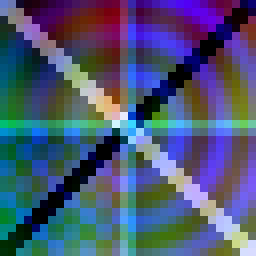

── Encoded input image ──
  saved encoded_image.png  (256x256)  [input after thermometer encoding (as-is)]


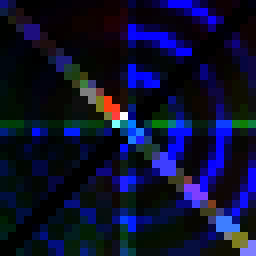


── Patch 0 (should match top-left 7×7 of input) ──
  saved 7x7_patch_0.png  (140x140)  [patch 0, inverse-decoded]


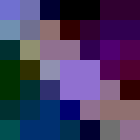

  saved 7x7_patch_0_encoded.png  (140x140)  [patch 0, as-is]


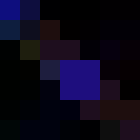


── Patch grid ──
  saved 7x7_patch_grid.png  (208x208)  [all patches at (x,y), inverse-decoded]


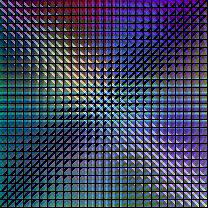

  saved 7x7_patch_grid_encoded.png  (208x208)  [all patches at (x,y), as-is]


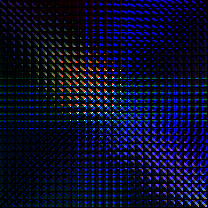


── Reconstruction from patches ──
  saved 7x7_patch_recon.png  (256x256)  [reconstruction, inverse-decoded]


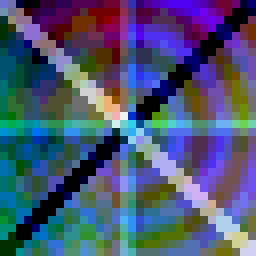

  saved 7x7_patch_recon_encoded.png  (256x256)  [reconstruction, as-is]


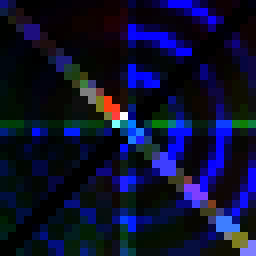


── Tiled reconstruction ──
  saved 7x7_tiled_recon.png  (256x256)  [tiled, inverse-decoded]


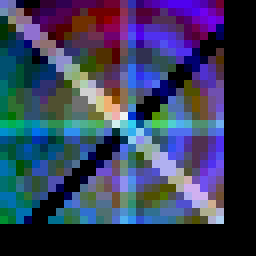

  saved 7x7_tiled_recon_encoded.png  (256x256)  [tiled, as-is]


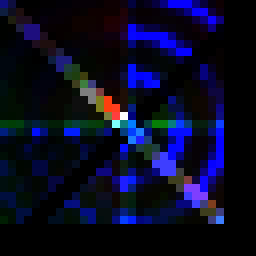


✓ All visualisations saved to data/patches_output_7x7/


In [9]:
# ── Cell 3: Visualise ─────────────────────────────────────────────────────────
SCALE = 8   # upscale factor for full 32×32 outputs

def save_show(img, filename, label, scale=1):
    if scale > 1:
        img = img.resize((img.width * scale, img.height * scale), Image.NEAREST)
    path = os.path.join(OUT_DIR, filename)
    img.save(path)
    print(f'  saved {filename}  ({img.width}x{img.height})  [{label}]')
    display(img)


print('── Original input image ──')
save_show(Image.fromarray(raw_arr), 'input_original.png', ..., scale=SCALE)

# ── Encoded input image ───────────────────────────────────────────────────────
print('── Encoded input image ──')
enc_arr = thermometer_encode_array(raw_arr)
save_show(
    encoded_image_to_pil(enc_arr, as_is=True),
    'encoded_image.png',
    'input after thermometer encoding (as-is)',
    scale=SCALE
)

# ── Patch 0 — top-left verification ──────────────────────────────────────────
# If the IP is correct, patch 0 must look like the top-left PS×PS corner.
print(f'\n── Patch 0 (should match top-left {PS}×{PS} of input) ──')
save_show(patch_to_image(patches[0], scale=20),
          f'{PS}x{PS}_patch_0.png',         'patch 0, inverse-decoded')
save_show(patch_to_image(patches[0], scale=20, as_is=True),
          f'{PS}x{PS}_patch_0_encoded.png', 'patch 0, as-is')

# ── Patch grid at decoded (x, y) positions ───────────────────────────────────
print('\n── Patch grid ──')
save_show(patches_to_grid(patches, cell=8, use_position=True, as_is=False),
          f'{PS}x{PS}_patch_grid.png',         'all patches at (x,y), inverse-decoded')
save_show(patches_to_grid(patches, cell=8, use_position=True, as_is=True),
          f'{PS}x{PS}_patch_grid_encoded.png', 'all patches at (x,y), as-is')

# ── Overlap-averaged reconstruction ──────────────────────────────────────────
print('\n── Reconstruction from patches ──')
save_show(reconstruct_image(patches, img_size=IMG_SIZE, as_is=False),
          f'{PS}x{PS}_patch_recon.png',         'reconstruction, inverse-decoded', scale=SCALE)
save_show(reconstruct_image(patches, img_size=IMG_SIZE, as_is=True),
          f'{PS}x{PS}_patch_recon_encoded.png', 'reconstruction, as-is',           scale=SCALE)

# ── Tiled reconstruction ──────────────────────────────────────────────────────
print('\n── Tiled reconstruction ──')
save_show(reconstruct_tiled(patches, img_size=IMG_SIZE, as_is=False),
          f'{PS}x{PS}_tiled_recon.png',         'tiled, inverse-decoded', scale=SCALE)
save_show(reconstruct_tiled(patches, img_size=IMG_SIZE, as_is=True),
          f'{PS}x{PS}_tiled_recon_encoded.png', 'tiled, as-is',           scale=SCALE)

print(f'\n✓ All visualisations saved to {OUT_DIR}/')

In [5]:
print('=' * 52)
print(f'Image      {IMG_SIZE}×{IMG_SIZE} pixels  ({ENC_BITS}-bit thermometer)')
print(f'Patch      {PS}×{PS}  →  {NUM_PATCHES} patches')
print(f'DMA recv   {NUM_PATCHES * WORDS_PER_PATCH * 4} bytes')
print(f'Output     {OUT_DIR}/')
for fn in sorted(os.listdir(OUT_DIR)):
    sz = os.path.getsize(os.path.join(OUT_DIR, fn))
    print(f'  {fn:<38} {sz:>9,} bytes')
print('=' * 52)

Image      32×32 pixels  (7-bit thermometer)
Patch      7×7  →  676 patches
DMA recv   91936 bytes
Output     data/patches_output_7x7/
  7x7_patch_0.png                              574 bytes
  7x7_patch_0_encoded.png                      587 bytes
  7x7_patch_1.png                              574 bytes
  7x7_patch_1_encoded.png                      587 bytes
  7x7_patch_grid.png                         8,665 bytes
  7x7_patch_grid_encoded.png                 6,551 bytes
  7x7_patch_recon.png                        2,911 bytes
  7x7_patch_recon_encoded.png                3,447 bytes
  7x7_tiled_recon.png                        2,509 bytes
  7x7_tiled_recon_encoded.png                2,942 bytes
  encoded_image.png                          3,447 bytes
  patches.npz                              114,866 bytes
  tb_output.txt                            729,074 bytes
